<a href="https://colab.research.google.com/github/ayumeisyahputri/Sistem-Informasi-Event-Mahasiswa-Fakultas-Ilmu-Komputer/blob/main/EEG_Seizure_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Membaca dataset...


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5



Melatih model Random Forest...

Akurasi Model: 97.96%

Laporan Klasifikasi secara Detail:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1835
           1       0.95      0.94      0.95       465

    accuracy                           0.98      2300
   macro avg       0.97      0.97      0.97      2300
weighted avg       0.98      0.98      0.98      2300



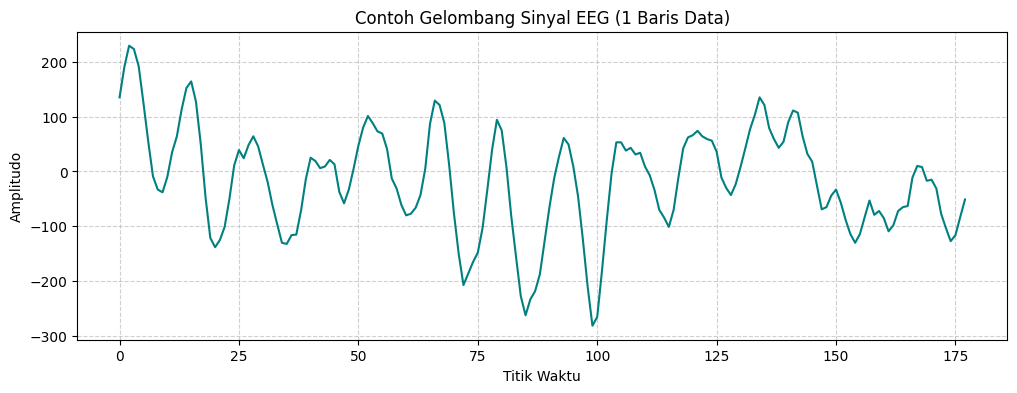

In [1]:
# 1. Mengimpor Library yang Dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2. Membaca Dataset
# Pastikan file CSV sudah berhasil di-upload ke Colab
print("Membaca dataset...")
df = pd.read_csv('Epileptic Seizure Recognition.csv')

# Menampilkan 5 baris pertama untuk melihat bentuk datanya
display(df.head())

# 3. Pra-pemrosesan Data (Data Preprocessing)
# Menghapus kolom index pertama ('Unnamed: 0') karena tidak terpakai untuk prediksi
if df.columns[0].startswith('Unnamed'):
    df = df.drop(df.columns[0], axis=1)

# Pada dataset ini, kolom target biasanya bernama 'y'
# Keterangan: y = 1 berarti terkena kejang (seizure), y = 2,3,4,5 berarti aktivitas normal/lainnya
# Kita ubah menjadi klasifikasi biner (1: Seizure, 0: Non-Seizure) untuk mempermudah
df['target'] = df['y'].apply(lambda x: 1 if x == 1 else 0)
df = df.drop('y', axis=1)

# Memisahkan Fitur (Sinyal EEG di variabel X) dan Target (Kondisi di variabel y)
X = df.drop('target', axis=1)
y = df['target']

# Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Melatih Model Klasifikasi (Machine Learning)
print("\nMelatih model Random Forest...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluasi Model
y_pred = model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n======================================")
print(f"Akurasi Model: {akurasi * 100:.2f}%")
print(f"======================================\n")

print("Laporan Klasifikasi secara Detail:")
print(classification_report(y_test, y_pred))

# 6. Visualisasi Sederhana untuk Portofolio
plt.figure(figsize=(12, 4))
plt.plot(X.iloc[0].values, color='teal')
plt.title("Contoh Gelombang Sinyal EEG (1 Baris Data)")
plt.xlabel("Titik Waktu")
plt.ylabel("Amplitudo")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()